In [1]:
source('../utilities/functions/frequency-longitudinal_boxplots.R')

In [2]:
keep_visits <- c('PreTx', 'EI', 'ASCT90d', 'ASCT1y', 'ASCT2y', 'Healthy')
keep_celltypes <- c(
  "CD14 Mono Core",
  "CD14 Mono ISG+",
  "CD16 Mono Core",
  "Int Mono"
)

comparisons_to_show <- list(
  c("PreTx", "EI"),
  c("EI", "ASCT90d"),
  c("ASCT90d", "ASCT1y"),
  c("ASCT1y", "ASCT2y"),
  c("PreTx", "Healthy"),
  c("EI", "Healthy"),
  c("ASCT90d", "Healthy"),
  c("ASCT1y", "Healthy"),
  c("ASCT2y", "Healthy")
)

In [3]:
# Load and process data
df <- fread('../../data/figure-inputs/frequency_files/bmmc_l3_frequency.csv')
df_processed <- process_frequency_data(df, keep_visits, keep_celltypes)

# Load and process p-values
manual_pvals <- fread('../../data/figure-inputs/l3-freq_results/bmmc_all_timepoint_frequency_results.csv')
pvals_positioned <- process_pvalue_data(
    manual_pvals,
    df_processed,
    keep_visits,
    keep_celltypes,
    comparisons_to_show
)

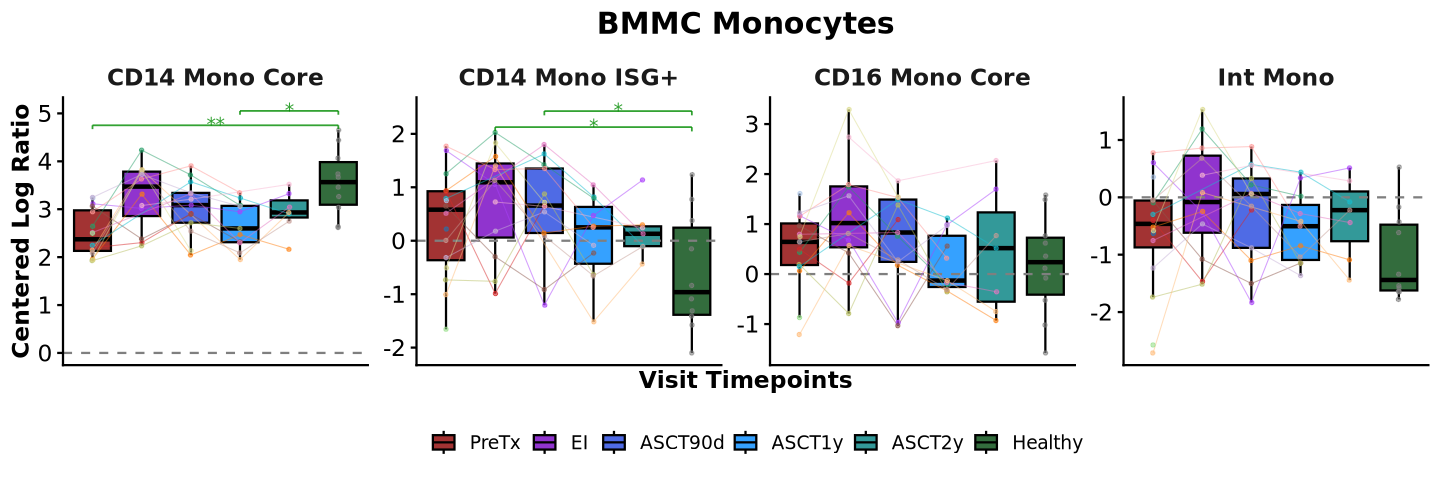

In [4]:
# Create plot with custom parameters
plot_params <- list(
    n_cols = 4,
    plot_title = "BMMC Monocytes",
    base_font_size = 14
)

p <- create_frequency_plot(
    df_processed,
    pvals_positioned,
    plot_params
)

plot_width = 12
plot_height = 4
plot_dpi = 200

options(repr.plot.width = plot_width, repr.plot.height = plot_height)
p

In [5]:
ggsave("../../data/figure-outputs/figure-3/fig_3e.pdf", plot = p, width = plot_width, height = plot_height, dpi = plot_dpi, device = cairo_pdf)